# Imports

In [53]:
%load_ext autoreload
%autoreload 2

from llmperf.config.workloads import get_workload_by_alias
from llmperf.postprocessing.output import ExperimentOutput
from typing import Dict, List
from collections import defaultdict
from eval_plots import plot_latency_breakdown, plot_grouped_bar_chart,\
    parse_logs, get_metric_fn, analyze_nested_data_change, filter_nested_data,\
    normalize_nested_data_to_base_frame, calculate_average_change_from_base,\
        calculate_average_relative_score, save_figure_as_pdf
# from llmperf.constants import EXPERIMENTS_LOG
MODAL_OUTPUTS = "/home/ioannis.dalianis/code/las_konpap/mllm-inference-workload-eval/artifacts/outputs/outputs-images"
EXPERIMENTS_LOG = "/home/ioannis.dalianis/code/las_konpap/mllm-inference-workload-eval/artifacts/outputs/benchmark-log-images.jsonl"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Evaluator Class

In [54]:
class Evaluator:
    def __init__(self, workload_alias: str, eo_id: str):
        self.workload = get_workload_by_alias(workload_alias)

        if len(self.workload.requests) == 0:
            self.workload.load()

        # self.eo = ExperimentOutput(id=eo_id)
        self.eo = ExperimentOutput(id=eo_id, output_path=MODAL_OUTPUTS)
        self.eo.load()

        assert len(self.workload.requests) == len(self.eo.request_outputs)

    def evaluate(self, metrics: List[str]) -> Dict[str, float]:
        scores = {}
        for metric in metrics:
            metric_fn = get_metric_fn(metric, self.workload.alias)
            score = metric_fn(
                self.workload.requests,
                self.eo.request_outputs
            )
            scores[metric] = score

        return scores

# Main

In [55]:
# Load experiment outputs from benchmark logs
experiment_ids = parse_logs(EXPERIMENTS_LOG)
print(experiment_ids.keys())

dict_keys(['mmbench-mc', 'llavabench-qna', 'cocoval-captioning'])


In [56]:
# check if scores already exists
try:
    scores
except NameError:
    scores = defaultdict(lambda: defaultdict(dict))
    
    ttfts = defaultdict(lambda: defaultdict(dict))
    avg_modality_tokens = defaultdict(lambda: defaultdict(dict))
    preprocess_times = defaultdict(lambda: defaultdict(dict))
    encoder_times = defaultdict(lambda: defaultdict(dict))
    
    prompt_preparation_times = defaultdict(lambda: defaultdict(dict))

    for wl_alias in experiment_ids.keys():
        print(f"Calculating for dataset {wl_alias}")
        if wl_alias in ["mmbench-mc", "videomme-mc"]:
            metric = "accuracy"
        else:
            metric = "rouge-l"

        for model in experiment_ids[wl_alias].keys():
            print(f"\tCalculating for model {model}")
            for cr in experiment_ids[wl_alias][model].keys():
                eo_id = experiment_ids[wl_alias][model][cr]
                
                try:
                    # 1. Attempt to access the deeply nested value directly.
                    # If any key is missing (wl_alias, model, or cr), a KeyError will be raised.
                    score_exists = scores[wl_alias][model][cr]
                except KeyError:
                    evaluator = Evaluator(wl_alias, eo_id)
                    score = evaluator.evaluate([metric])
                    scores[wl_alias][model][cr] = score[metric]

                eo = ExperimentOutput(id=eo_id, output_path=MODAL_OUTPUTS)
                eo.load()
                ttft = eo.ttft_latency("mean")
                ttfts[wl_alias][model][cr] = ttft
                
                preprocess_time = eo.preprocess_times("mean")
                preprocess_times[wl_alias][model][cr] = preprocess_time
                
                encoder_time = eo.encoder_times("mean")
                encoder_times[wl_alias][model][cr] = encoder_time

                avg_modality_token = eo.avg_modality_tokens("mean")
                avg_modality_tokens[wl_alias][model][cr] = avg_modality_token

                prompt_preparation_times[wl_alias][model][cr] = eo.avg_prompt_preparation_time("mean")

In [57]:
for i in scores:
    print(i)
# scores
# preprocess_times
# encoder_times
# ttfts
# prompt_preparation_times

mmbench-mc
llavabench-qna
cocoval-captioning


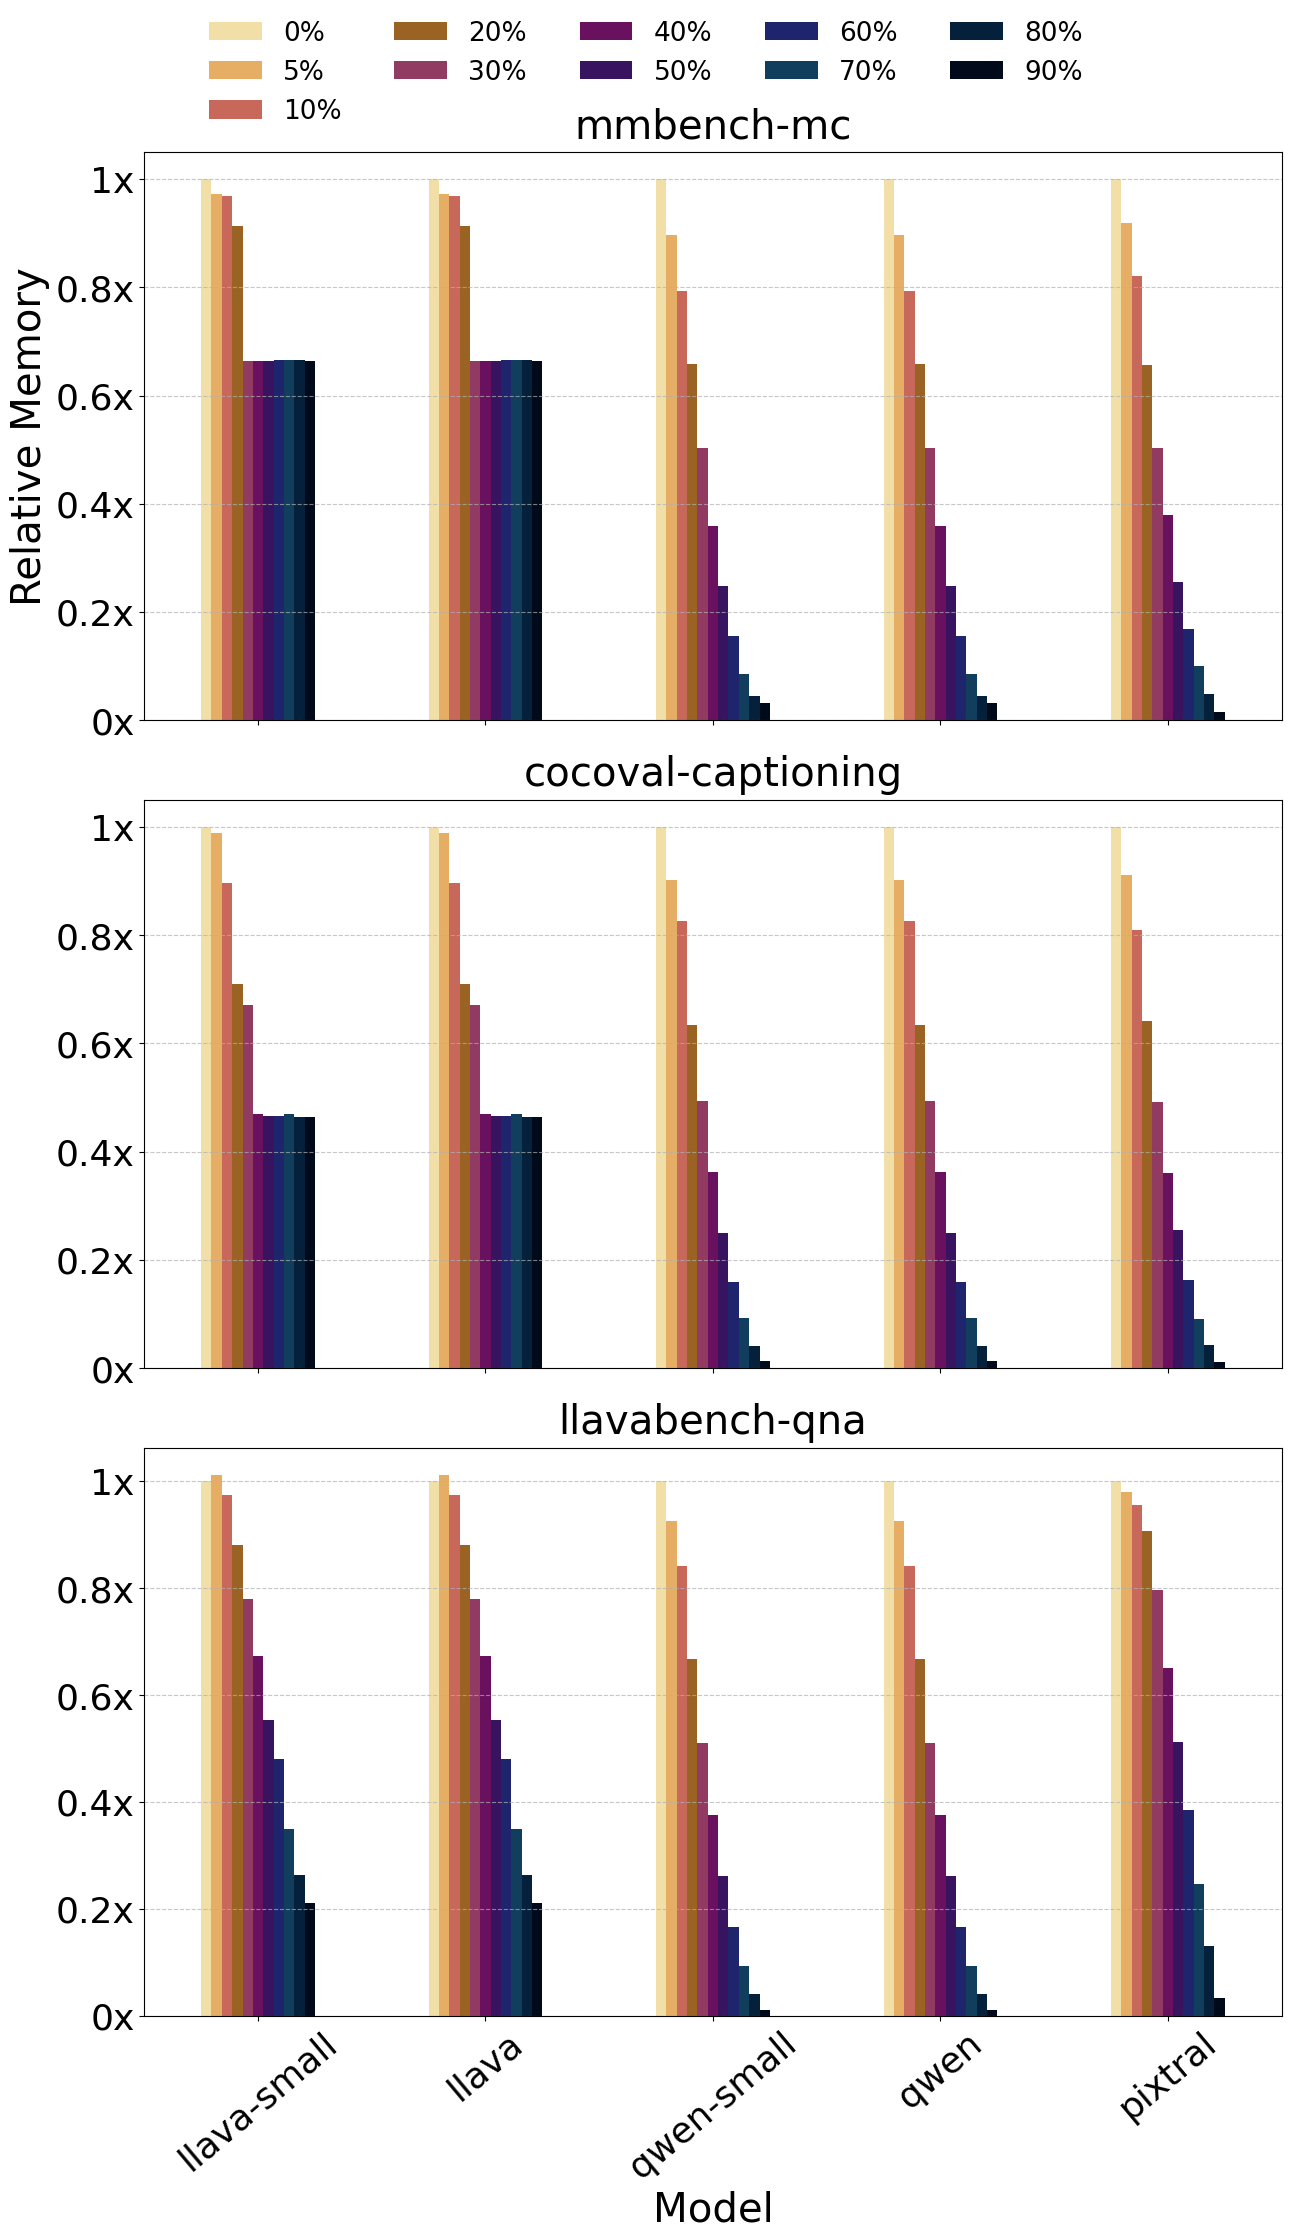

Saving plot to /home/ioannis.dalianis/code/las_konpap/mllm-inference-workload-eval/artifacts/figures/img_datasets_relative_memory.pdf


In [ ]:
# fig = plot_grouped_bar_chart(scores, ["mmbench-mc", "cocoval-captioning", "llavabench-qna"], show_legend=True)
# save_figure_as_pdf(fig, "img_datasets_metric_scores")

# # fig = plot_grouped_bar_chart(ttfts, ["mmbench-mc", "cocoval-captioning", "llavabench-qna"], show_legend=True, tit="Relative Latency", add_suffix=True)
# ttft_reductions = normalize_nested_data_to_base_frame(ttfts, direction='big_to_small')
# fig = plot_grouped_bar_chart(ttft_reductions, ["mmbench-mc", "cocoval-captioning", "llavabench-qna"], show_legend=True, tit="Relative Latency (s)", add_suffix=True)
# # save_figure_as_pdf(fig, "img_datasets_relative_latency")

tokens_reductions = normalize_nested_data_to_base_frame(avg_modality_tokens, direction='big_to_small')
fig = plot_grouped_bar_chart(tokens_reductions, ["mmbench-mc", "cocoval-captioning", "llavabench-qna"], show_legend=True, tit="Relative Memory", add_suffix=True)
# save_figure_as_pdf(fig, "img_datasets_relative_memory")

Plotting for task llavabench-qna


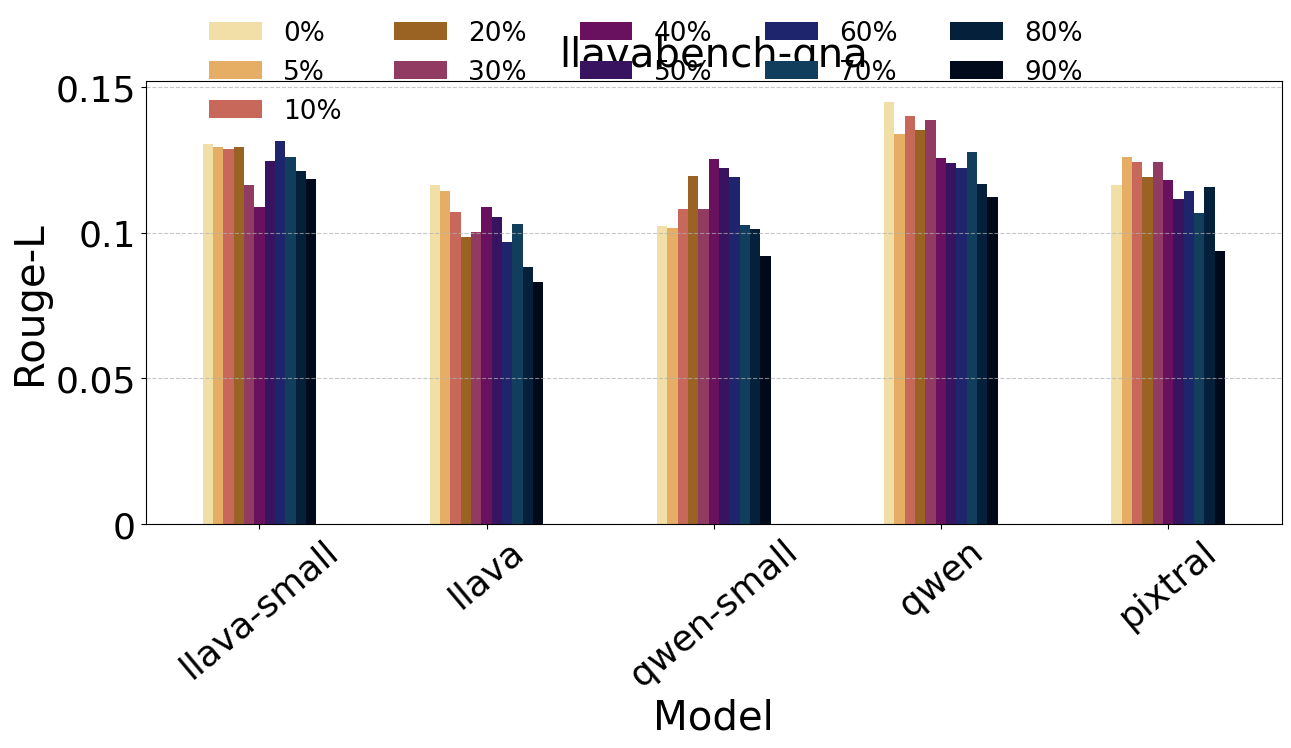

Average change from baseline: -4.82600809787878 %


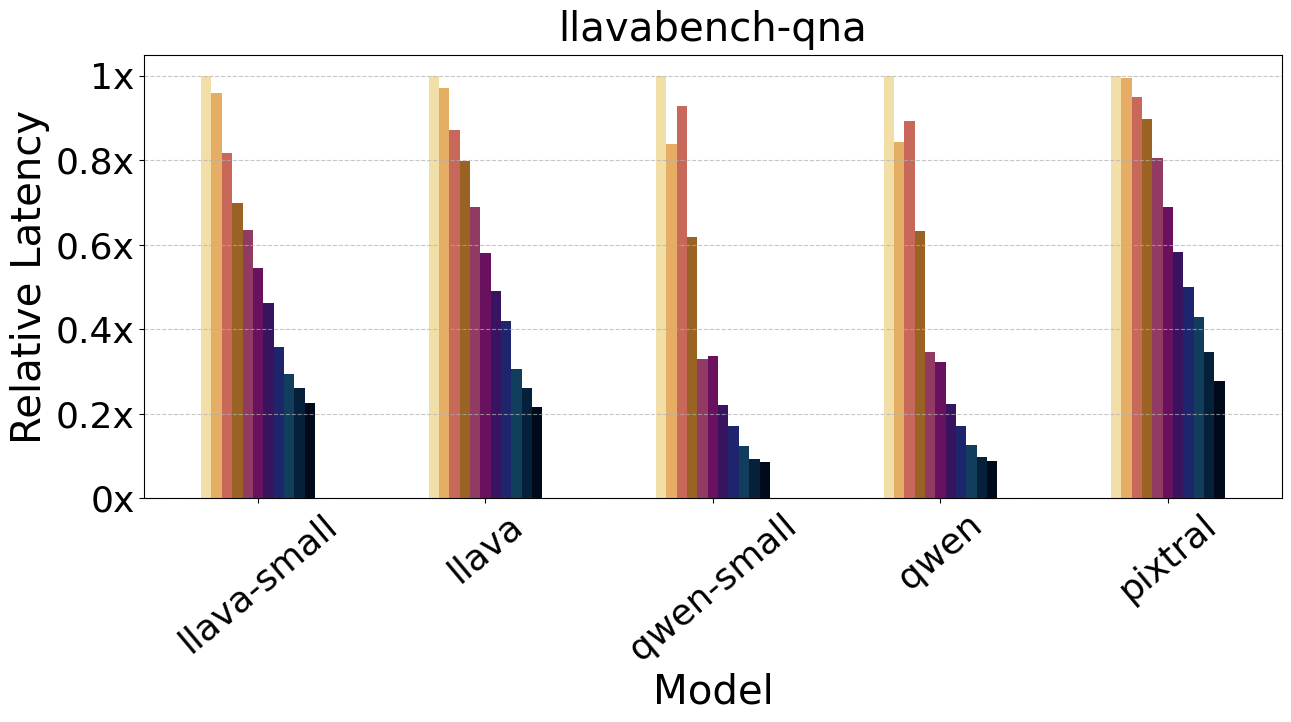

The final average percentage reduction of the relative latency for the image reduction percentages is: 0.49629400420618613 % according to their baselines


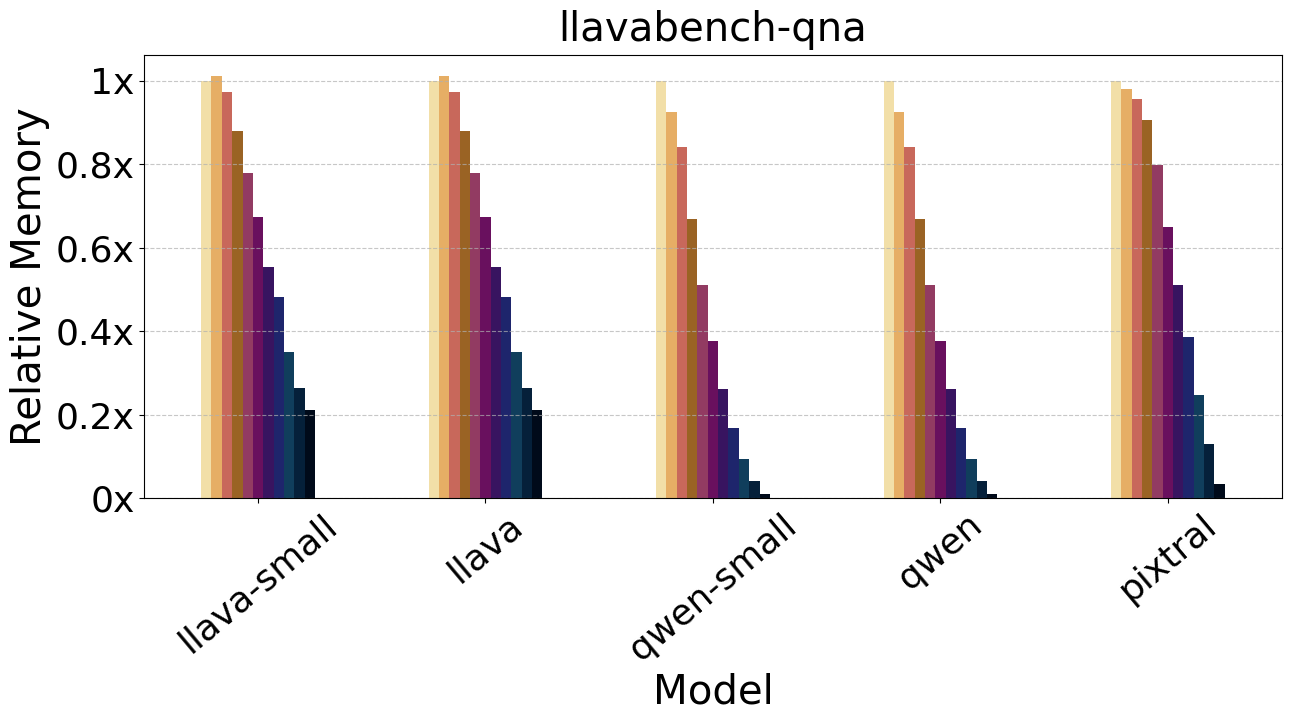

Average relative memory reduction: 0.515014936746457


In [59]:
tasks = [
    # "mmbench-mc",
    # "cocoval-captioning",
    "llavabench-qna",
]

for task in tasks:
    print(f"Plotting for task {task}")

    if task == "mmbench-mc":
        tit="Accuracy"
    else:
        tit="Rouge-L"

    scores_only_task = filter_nested_data(
        scores,
        remove_tasks = experiment_ids.keys() - {task},
        remove_models={}, 
        remove_frames={}, 
        remove_techniques={}
    )
    ttfts_only_task = filter_nested_data(
        ttfts,
        remove_tasks = experiment_ids.keys() - {task},
        remove_models={}, 
        remove_frames={}, 
        remove_techniques={}
    )
    plot_grouped_bar_chart(scores, task, tit=tit, show_legend=True)
    print("Average change from baseline:",
        calculate_average_change_from_base(data_structure=scores_only_task, comparison_key=0.0)[0], "%"
    )
    # analyze_nested_data_change(scores_only_task, direction='small_to_big', comparison_mode='first', show_keys=["0.0", 60.0])

    ttft_reductions = normalize_nested_data_to_base_frame(ttfts_only_task, direction='big_to_small')
    plot_grouped_bar_chart(ttft_reductions, task, tit="Relative Latency", show_legend=False, add_suffix=True)
    print("The final average percentage reduction of the relative latency for the image reduction percentages is:",
        calculate_average_relative_score(data_structure=ttft_reductions, comparison_key=0.0), "% according to their baselines"
    )
    
    tokens_reductions = normalize_nested_data_to_base_frame(avg_modality_tokens, direction='big_to_small')
    tokens_reductions_only_task = filter_nested_data(
        tokens_reductions,
        remove_tasks = experiment_ids.keys() - {task},
        remove_models={}, 
        remove_frames={}, 
        remove_techniques={}
    )
    plot_grouped_bar_chart(tokens_reductions_only_task, task, tit="Relative Memory", show_legend=False, add_suffix=True)
    print("Average relative memory reduction:",
        calculate_average_relative_score(data_structure=tokens_reductions_only_task, comparison_key=0.0)
    )

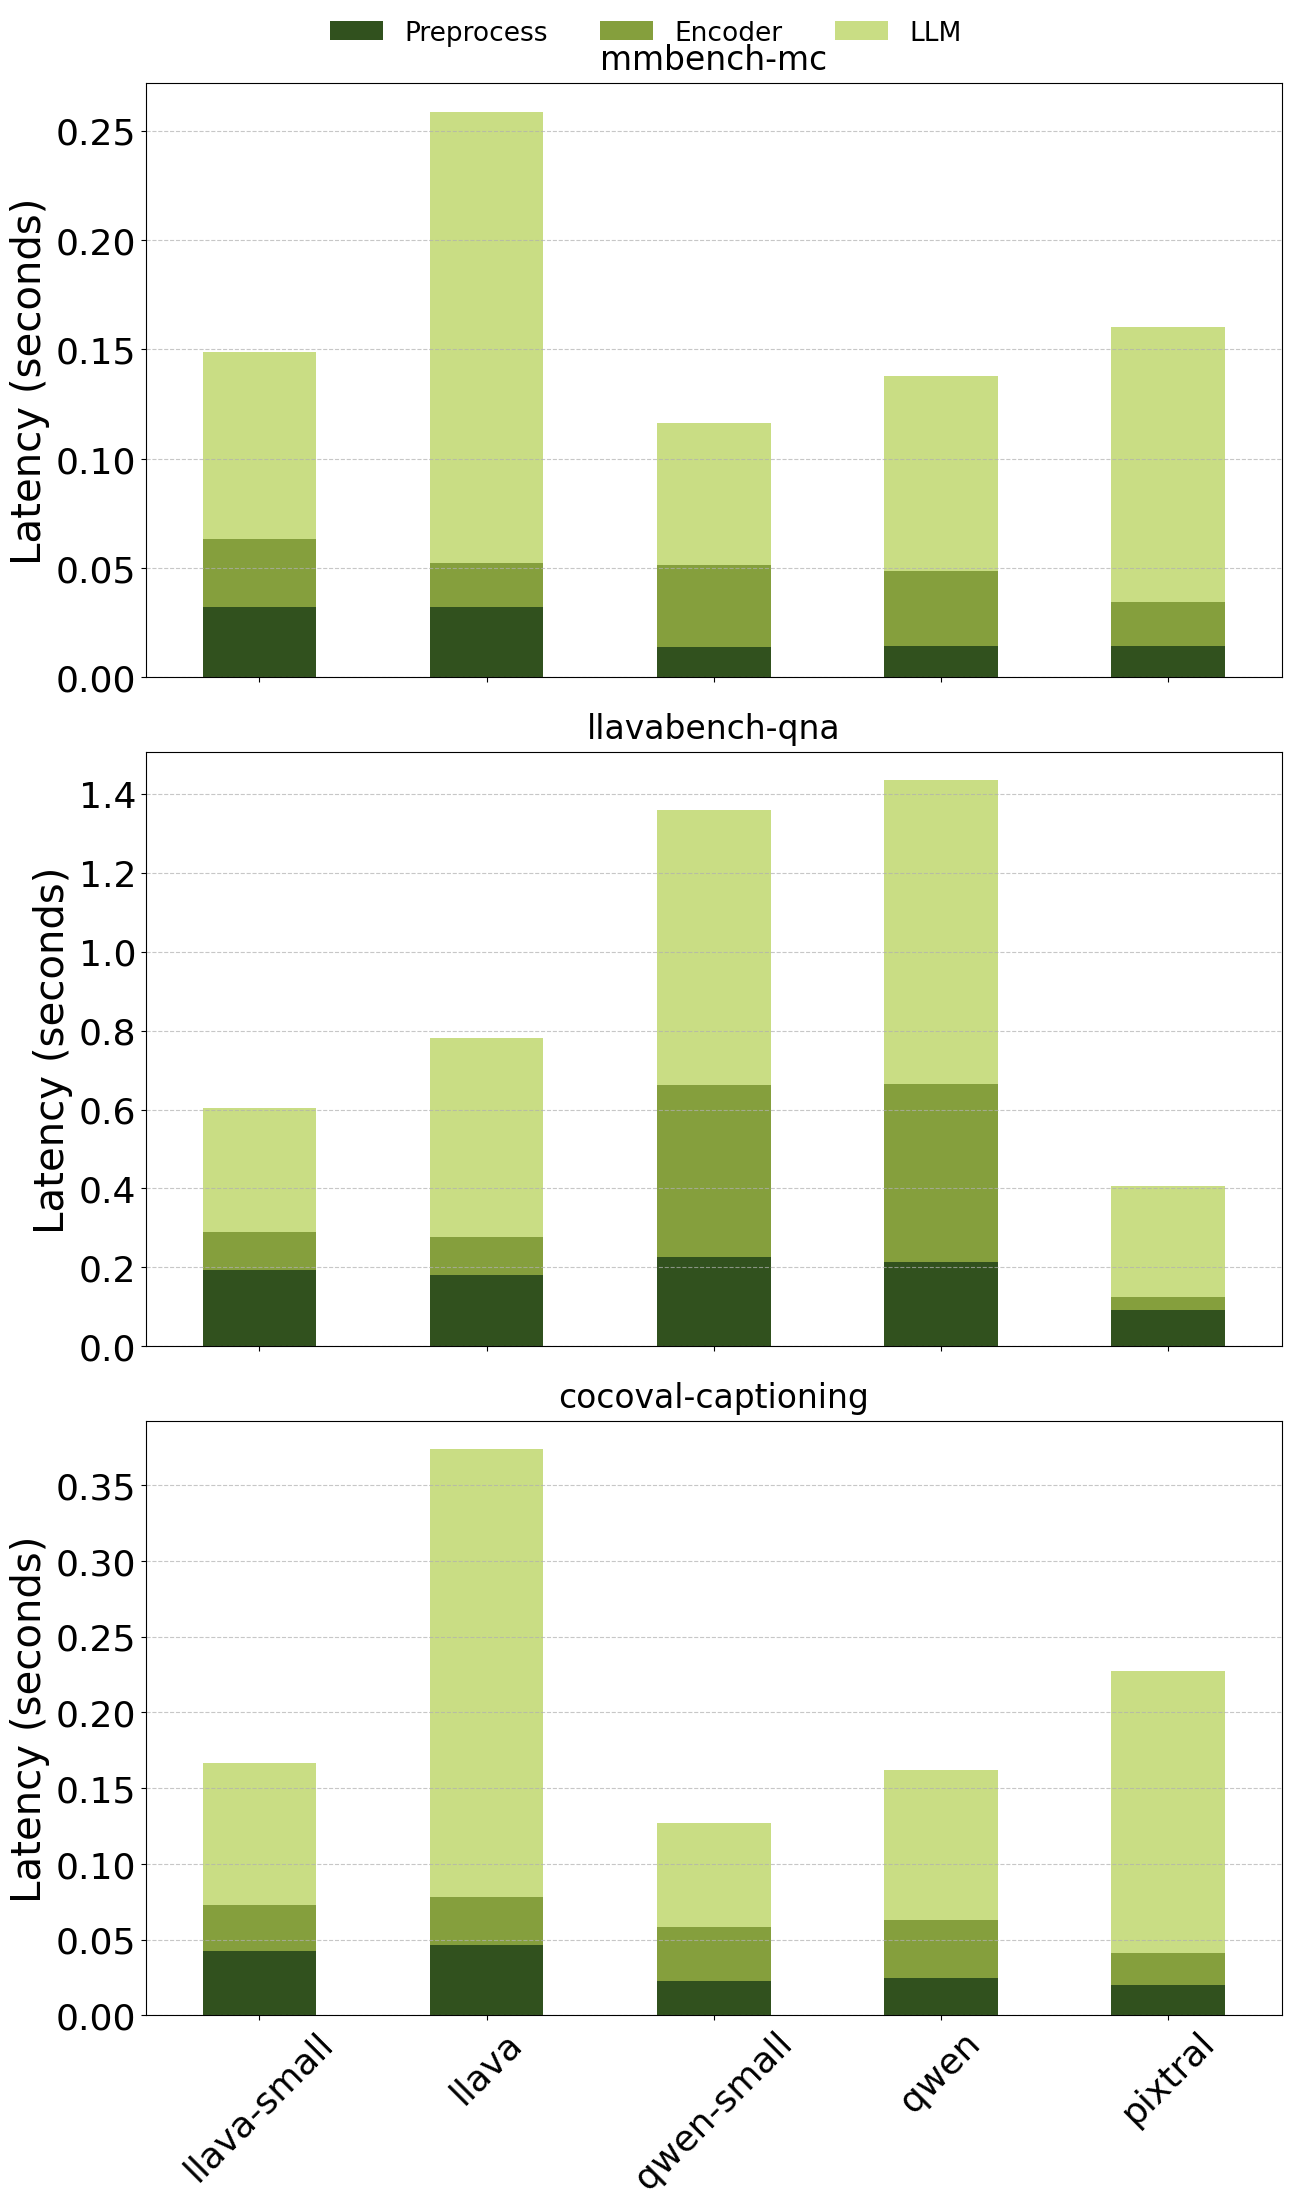

In [60]:
# plot_latency_breakdown(preprocess_times, encoder_times, ttfts, dataset_name='mmbench-mc')
fig = plot_latency_breakdown(preprocess_times, encoder_times, ttfts, dataset_name=['mmbench-mc', 'llavabench-qna', 'cocoval-captioning'])
# save_figure_as_pdf(fig, "image_latency_breakdown")